# Project 01 — PBMC 3K: Reference scRNA-seq Pipeline

**Author:** Marko Živanović, PhD  
**Tool:** Scanpy (Python)  
**Dataset:** 10X Genomics PBMC 3K — peripheral blood mononuclear cells from a healthy donor  
**Purpose:** Reference end-to-end scRNA-seq workflow on a widely recognized benchmark dataset.

## Pipeline overview
1. Setup & data loading
2. Quality control
3. Normalization & feature selection
4. Dimensionality reduction (PCA, UMAP)
5. Leiden clustering
6. Marker gene identification
7. Cell type annotation
8. Publication figures (hero UMAP, marker heatmap, dotplot, violin)
9. Export results

## 1. Setup

In [1]:
import sys
from pathlib import Path

# add shared helpers to path
sys.path.append(str(Path('../../_shared/scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad

import portfolio_utils as pu
pu.setup_plotting(style_path='../../_shared/styles/portfolio.mplstyle')

# project directories
DATA_DIR    = Path('../data')
FIG_DIR     = Path('../figures')
RESULTS_DIR = Path('../results')
for d in (DATA_DIR, FIG_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sc.settings.verbosity = 1
sc.logging.print_header()

Package,Version
numpy,2.4.6
pandas,2.3.3
matplotlib,3.9.1
seaborn,0.13.2
scanpy,1.11.5
anndata,0.12.16
Component,Info
Python,"3.11.15 | packaged by conda-forge | (main, Mar 5 2026, 16:45:40) [GCC 14.3.0]"
OS,Linux-6.17.0-23-generic-x86_64-with-glibc2.39
CPU,"16/16 logical CPU cores, x86_64"


## 2. Load data

PBMC 3K is bundled with Scanpy. First call downloads it; subsequent calls use the cache.

In [2]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
print(adata)
print(f"\nShape: {adata.n_obs} cells × {adata.n_vars} genes")

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

Shape: 2700 cells × 32738 genes


## 3. Quality control

Three standard QC metrics:
- **n_genes_by_counts** — number of expressed genes per cell
- **total_counts** — total UMIs per cell
- **pct_counts_mt** — fraction of mitochondrial reads (high = dying cells)

In [3]:
# annotate gene categories
adata.var['mt']   = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt', 'ribo'],
    percent_top=None,
    log1p=False,
    inplace=True,
)

print("QC metrics computed.")
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe().round(1))

QC metrics computed.
       n_genes_by_counts  total_counts  pct_counts_mt
count             2700.0        2700.0         2700.0
mean               847.0        2366.9            2.2
std                282.1        1094.3            1.2
min                212.0         548.0            0.0
25%                690.0        1757.8            1.5
50%                817.0        2197.0            2.0
75%                953.2        2763.0            2.6
max               3422.0       15844.0           22.6


### Figure: QC distributions (pre-filtering)

  saved ../figures/01_qc_violins_prefilter.png
  saved ../figures/01_qc_violins_prefilter.tiff
  saved ../figures/01_qc_violins_prefilter.pdf


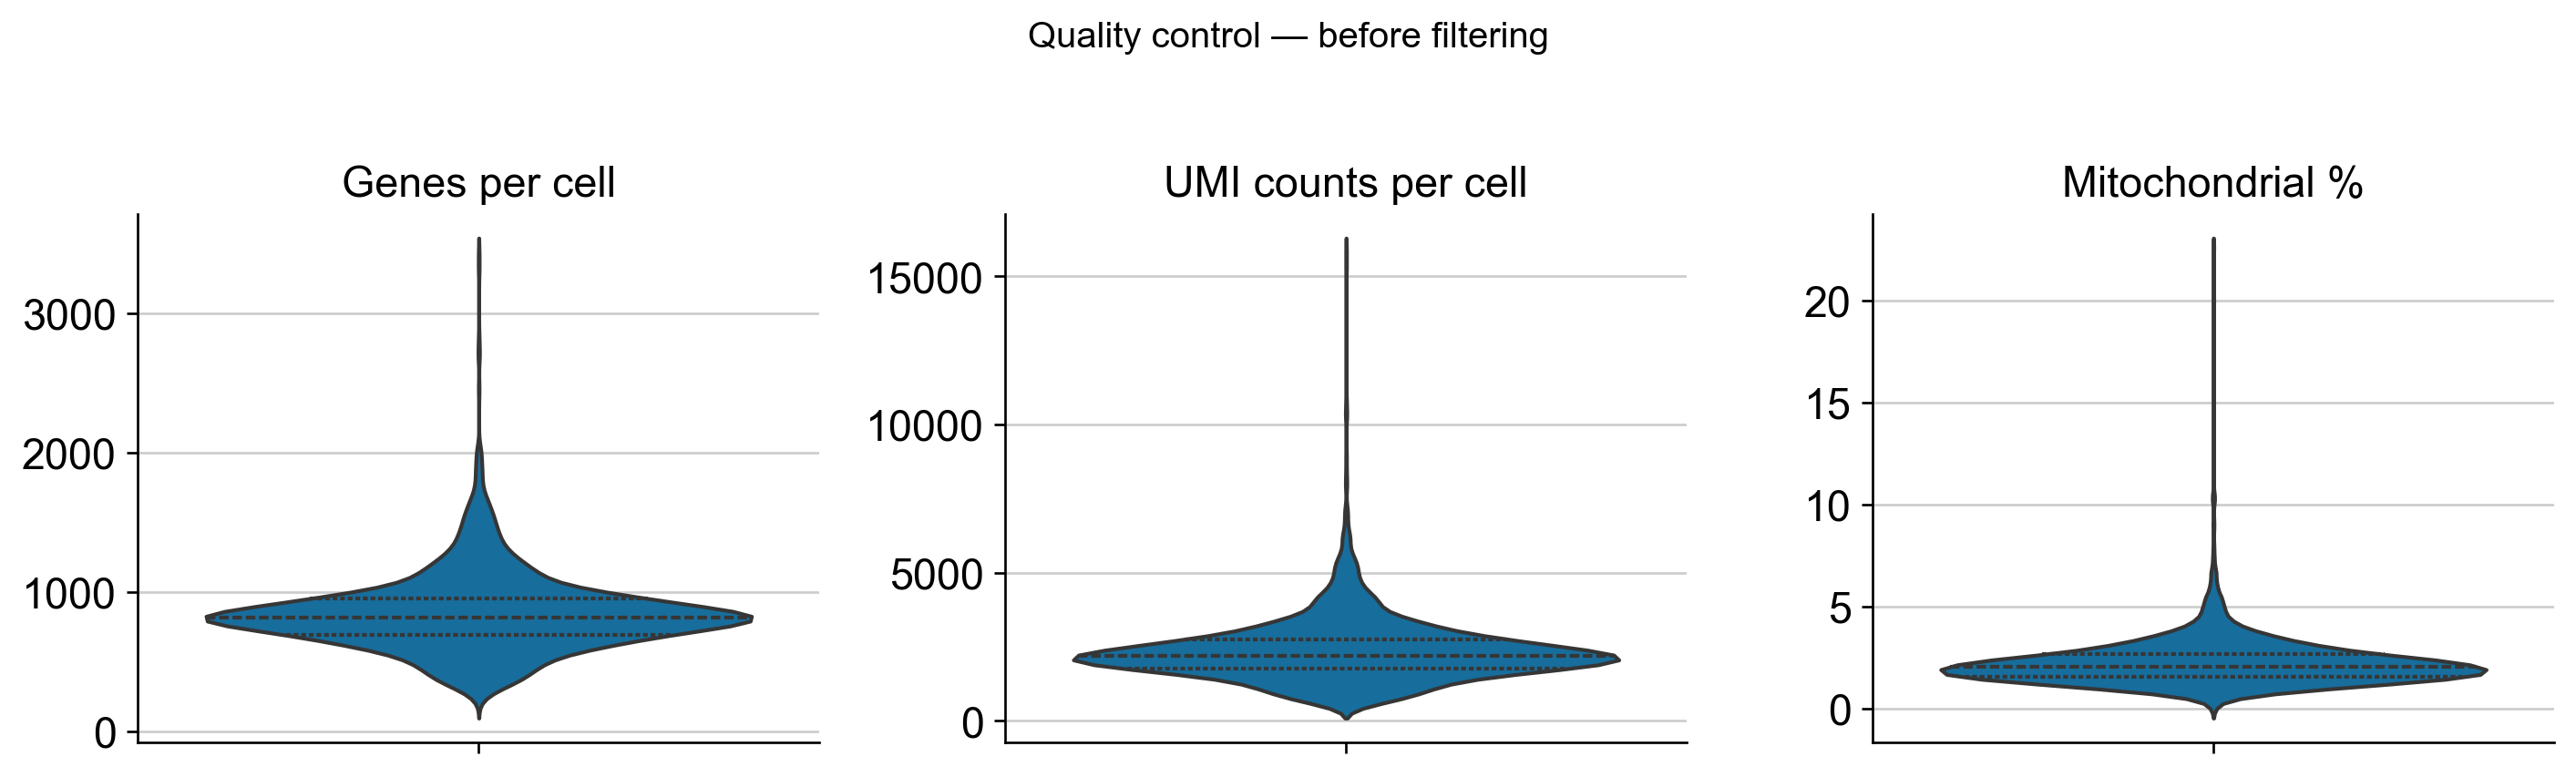

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
metrics = ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']
titles  = ['Genes per cell', 'UMI counts per cell', 'Mitochondrial %']
for ax, m, t in zip(axes, metrics, titles):
    sns.violinplot(y=adata.obs[m], ax=ax, color='#0173B2', inner='quartile')
    ax.set_title(t)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.suptitle('Quality control — before filtering', y=1.02, fontsize=12)
fig.tight_layout()
pu.save_figure(fig, '01_qc_violins_prefilter', out_dir=FIG_DIR)
plt.show()

### Apply QC filters

Standard thresholds for PBMC 3K (based on community best practice + the distributions above):
- Cells: 200 ≤ n_genes ≤ 2500, pct_mt < 5%
- Genes: expressed in at least 3 cells

In [5]:
n_cells_before = adata.n_obs
n_genes_before = adata.n_vars

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

print(f"Cells:  {n_cells_before} → {adata.n_obs} (removed {n_cells_before - adata.n_obs})")
print(f"Genes:  {n_genes_before} → {adata.n_vars} (removed {n_genes_before - adata.n_vars})")

Cells:  2700 → 2638 (removed 62)
Genes:  32738 → 13714 (removed 19024)


## 4. Normalization & feature selection

In [6]:
# keep the raw counts for downstream
adata.layers['counts'] = adata.X.copy()

# normalize to 10k counts per cell, log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat', subset=False)

# freeze the normalized expression as .raw for later marker plotting
adata.raw = adata

print(f"HVGs selected: {adata.var.highly_variable.sum()}")

HVGs selected: 2000


### Figure: HVG selection

  saved ../figures/02_hvg_selection.png


  saved ../figures/02_hvg_selection.tiff


  saved ../figures/02_hvg_selection.pdf


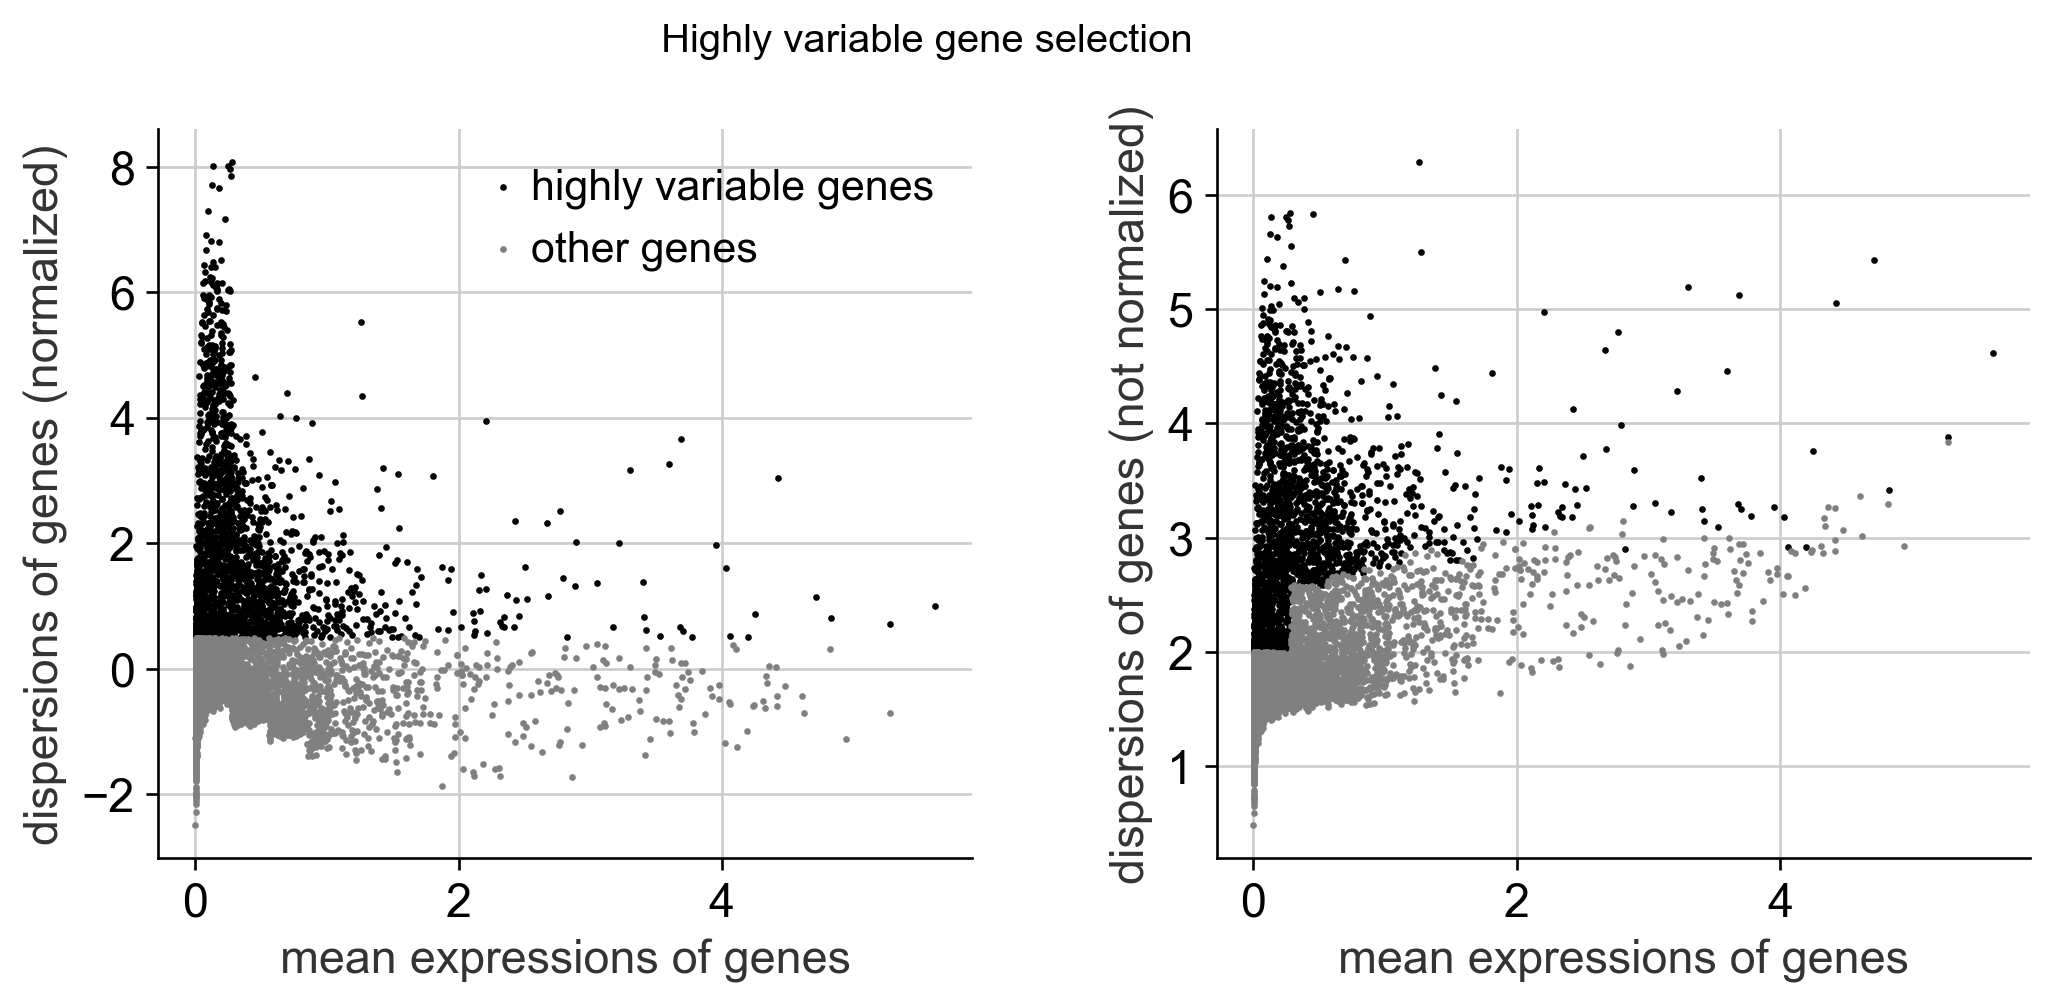

In [7]:
fig = sc.pl.highly_variable_genes(adata, show=False, save=None)
plt.gcf().suptitle('Highly variable gene selection', y=1.02)
pu.save_figure(plt.gcf(), '02_hvg_selection', out_dir=FIG_DIR)
plt.show()

## 5. Dimensionality reduction & clustering

- Scale → PCA (50 PCs) → kNN graph → UMAP → Leiden clustering

In [8]:
# scale on HVGs only
sc.pp.scale(adata, max_value=10)

# PCA
sc.tl.pca(adata, n_comps=50, svd_solver='arpack', random_state=RANDOM_SEED)

# neighborhood graph + UMAP
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=RANDOM_SEED)
sc.tl.umap(adata, random_state=RANDOM_SEED)

# Leiden clustering
sc.tl.leiden(adata, resolution=0.5, random_state=RANDOM_SEED, flavor='igraph', n_iterations=2, directed=False)

print(f"Number of Leiden clusters: {adata.obs['leiden'].nunique()}")

/home/marko-b2/miniconda3/envs/scportfolio/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Number of Leiden clusters: 7


### Figure: PCA variance explained

  saved ../figures/03_pca_scree.png
  saved ../figures/03_pca_scree.tiff
  saved ../figures/03_pca_scree.pdf


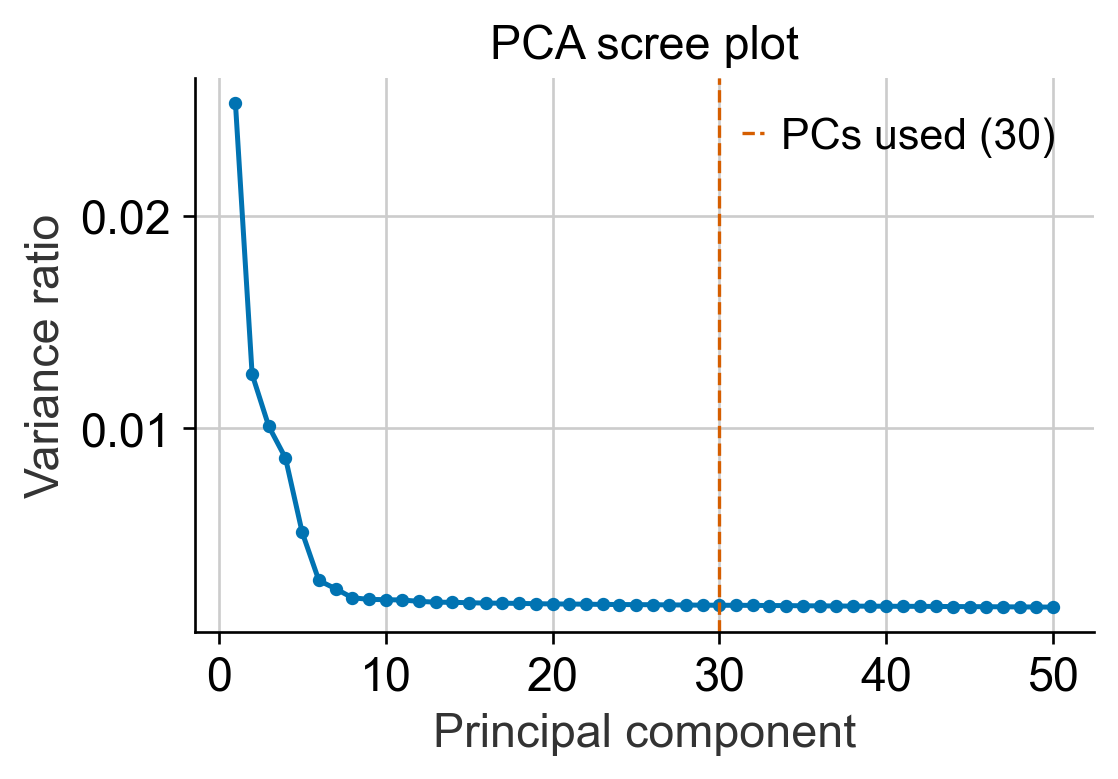

In [9]:
fig, ax = plt.subplots(figsize=(5, 3.5))
var = adata.uns['pca']['variance_ratio']
ax.plot(np.arange(1, len(var)+1), var, marker='o', markersize=3, color='#0173B2')
ax.set_xlabel('Principal component')
ax.set_ylabel('Variance ratio')
ax.set_title('PCA scree plot')
ax.axvline(30, color='#D55E00', linestyle='--', linewidth=1, label='PCs used (30)')
ax.legend()
fig.tight_layout()
pu.save_figure(fig, '03_pca_scree', out_dir=FIG_DIR)
plt.show()

### Figure: UMAP colored by Leiden clusters

  saved ../figures/04_umap_leiden.png
  saved ../figures/04_umap_leiden.tiff


  saved ../figures/04_umap_leiden.pdf


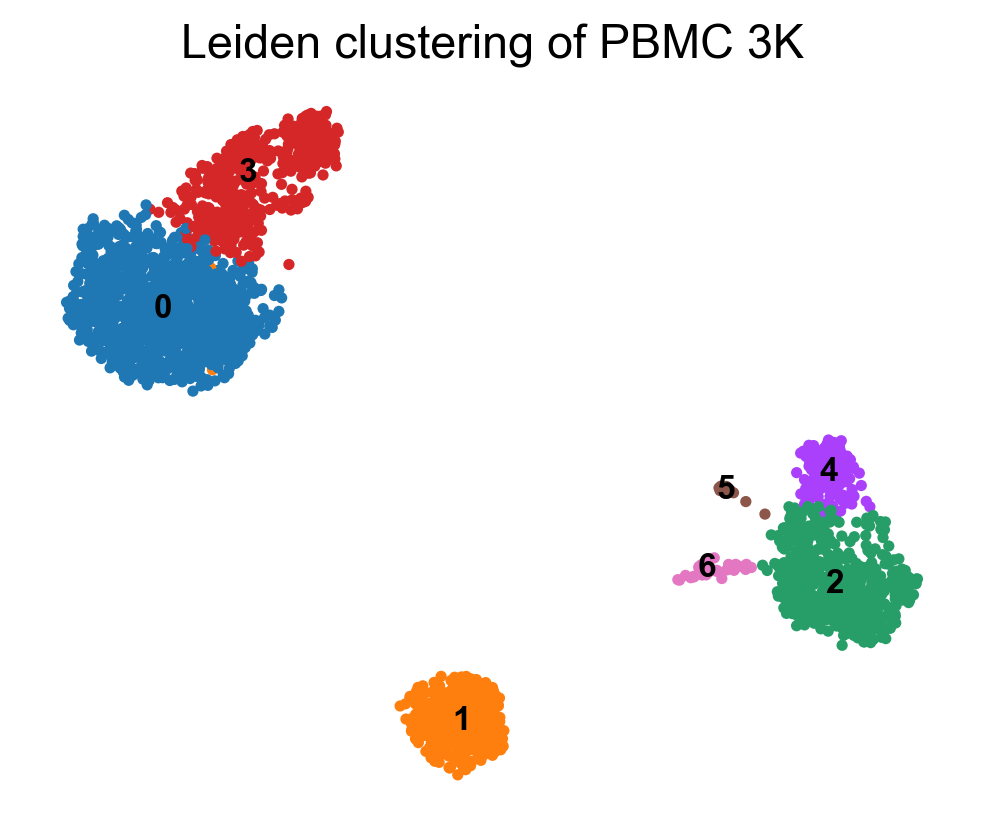

In [10]:
fig = sc.pl.umap(
    adata,
    color='leiden',
    legend_loc='on data',
    legend_fontsize=10,
    title='Leiden clustering of PBMC 3K',
    frameon=False,
    return_fig=True,
)
pu.save_figure(fig, '04_umap_leiden', out_dir=FIG_DIR)
plt.show()

## 6. Marker gene identification

In [11]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon', n_genes=200)

# extract top 5 markers per cluster into a dataframe
top_markers = pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(5)
print("Top 5 markers per cluster:")
print(top_markers)

Top 5 markers per cluster:
       0         1       2     3       4      5         6
0   LDHB      CD74     LYZ  NKG7    LST1    PF4  HLA-DPA1
1  RPS12     CD79A  S100A9  CST7  FCGR3A   PPBP  HLA-DPB1
2  RPS25   HLA-DRA  S100A8  GZMA  FCER1G   NRGN   HLA-DRA
3  RPS27     CD79B  TYROBP   B2M    AIF1   GPX1  HLA-DRB1
4   RPS3  HLA-DPB1     FTL  CCL5   COTL1  RGS18      CD74


### Figure: Top marker genes per cluster

  saved ../figures/05_top_markers_per_cluster.png


  saved ../figures/05_top_markers_per_cluster.tiff
  saved ../figures/05_top_markers_per_cluster.pdf


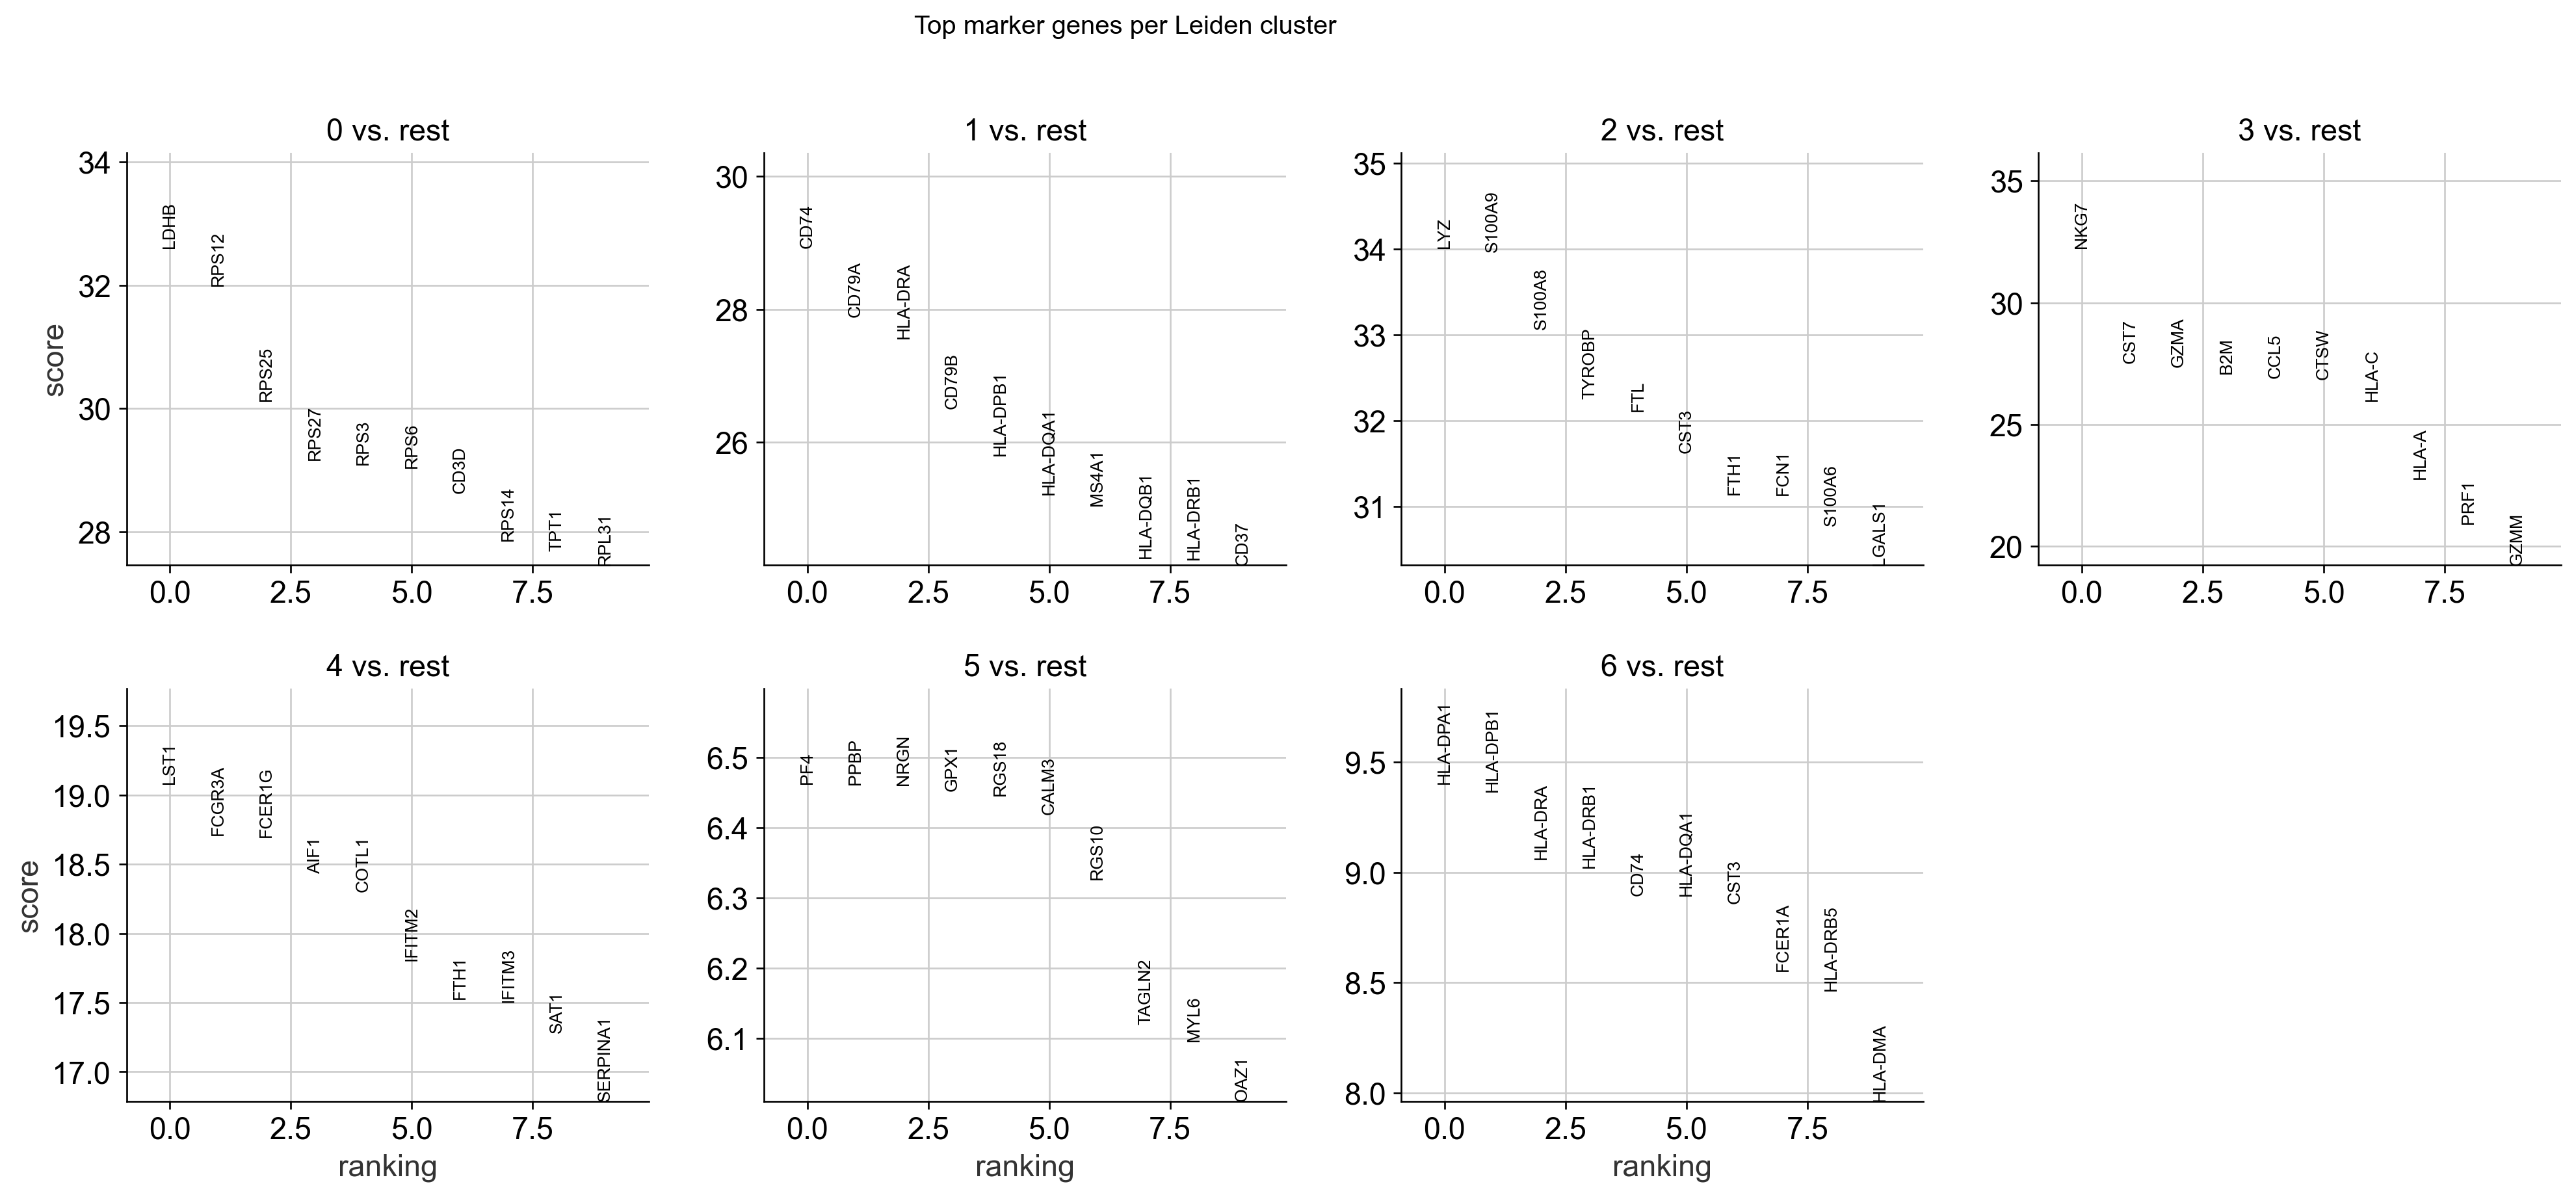

In [12]:
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False, show=False)
fig = plt.gcf()
fig.suptitle('Top marker genes per Leiden cluster', y=1.02)
pu.save_figure(fig, '05_top_markers_per_cluster', out_dir=FIG_DIR)
plt.show()

## 7. Cell type annotation

Canonical PBMC markers (Zheng et al. 2017; standard 10X tutorial):

| Cell type | Markers |
|-----------|---------|
| CD4 T cells | IL7R, CCR7 |
| CD8 T cells | CD8A, CD8B |
| NK cells | GNLY, NKG7 |
| B cells | CD79A, MS4A1 |
| CD14+ monocytes | CD14, LYZ |
| FCGR3A+ monocytes | FCGR3A, MS4A7 |
| Dendritic cells | FCER1A, CST3 |
| Platelets | PPBP |

  saved ../figures/06_marker_dotplot_byCluster.png
  saved ../figures/06_marker_dotplot_byCluster.tiff


  saved ../figures/06_marker_dotplot_byCluster.pdf


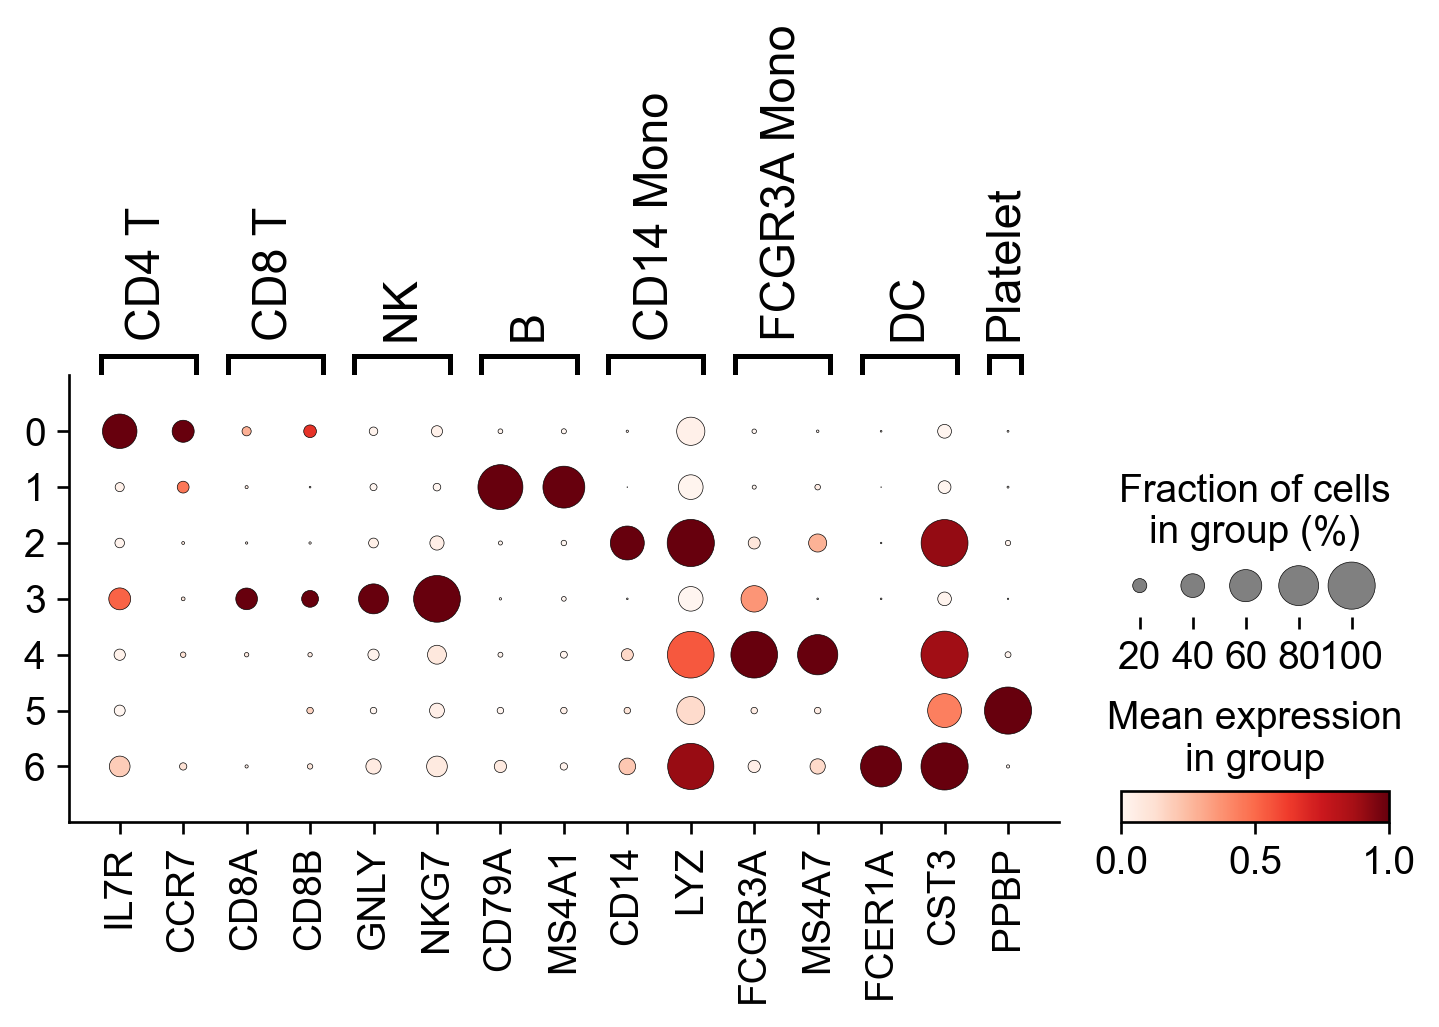

In [13]:
marker_genes = {
    'CD4 T':       ['IL7R', 'CCR7'],
    'CD8 T':       ['CD8A', 'CD8B'],
    'NK':          ['GNLY', 'NKG7'],
    'B':           ['CD79A', 'MS4A1'],
    'CD14 Mono':   ['CD14', 'LYZ'],
    'FCGR3A Mono': ['FCGR3A', 'MS4A7'],
    'DC':          ['FCER1A', 'CST3'],
    'Platelet':    ['PPBP'],
}

# inspect markers visually before assigning
sc.pl.dotplot(adata, marker_genes, groupby='leiden', standard_scale='var',
              show=False, save=None)
fig = plt.gcf()
pu.save_figure(fig, '06_marker_dotplot_byCluster', out_dir=FIG_DIR)
plt.show()

### Manual annotation

Based on the dotplot above, map each Leiden cluster to a canonical PBMC cell type.

**IMPORTANT:** Cluster IDs depend on the random seed and Leiden resolution. After running the cell above, **inspect the dotplot and update the mapping below** if cluster numbers differ from what the markers indicate.

In [14]:
# Cluster-to-celltype mapping based on observed top marker genes per cluster
# Cluster 0: LDHB, RPS* (CD4 T naive)
# Cluster 1: CD79A, MS4A1, HLA-DRA (B cells)
# Cluster 2: LYZ, S100A9, CD14 (CD14 Mono)
# Cluster 3: NKG7, GZMA, CCL5 (CD8 T / cytotoxic)
# Cluster 4: FCGR3A, MS4A7, LST1 (FCGR3A Mono)
# Cluster 5: PPBP, PF4 (Platelets)
# Cluster 6: HLA-DR*, CD74 (DC)
cluster_to_celltype = {
    '0': 'CD4 T',
    '1': 'B',
    '2': 'CD14 Mono',
    '3': 'CD8 T',
    '4': 'FCGR3A Mono',
    '5': 'Platelet',
    '6': 'DC',
}

# extend with default for any extra clusters
for cl in adata.obs['leiden'].cat.categories:
    if cl not in cluster_to_celltype:
        cluster_to_celltype[cl] = f'Cluster {cl}'

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype).astype('category')

print("Cell type counts:")
print(adata.obs['cell_type'].value_counts())

Cell type counts:
cell_type
CD4 T          1174
CD14 Mono       496
CD8 T           434
B               342
FCGR3A Mono     142
DC               36
Platelet         14
Name: count, dtype: int64


### Figure: HERO UMAP — annotated cell types (Upwork thumbnail)

  saved ../figures/hero_umap_celltypes.png


  saved ../figures/hero_umap_celltypes.tiff


  saved ../figures/hero_umap_celltypes.pdf


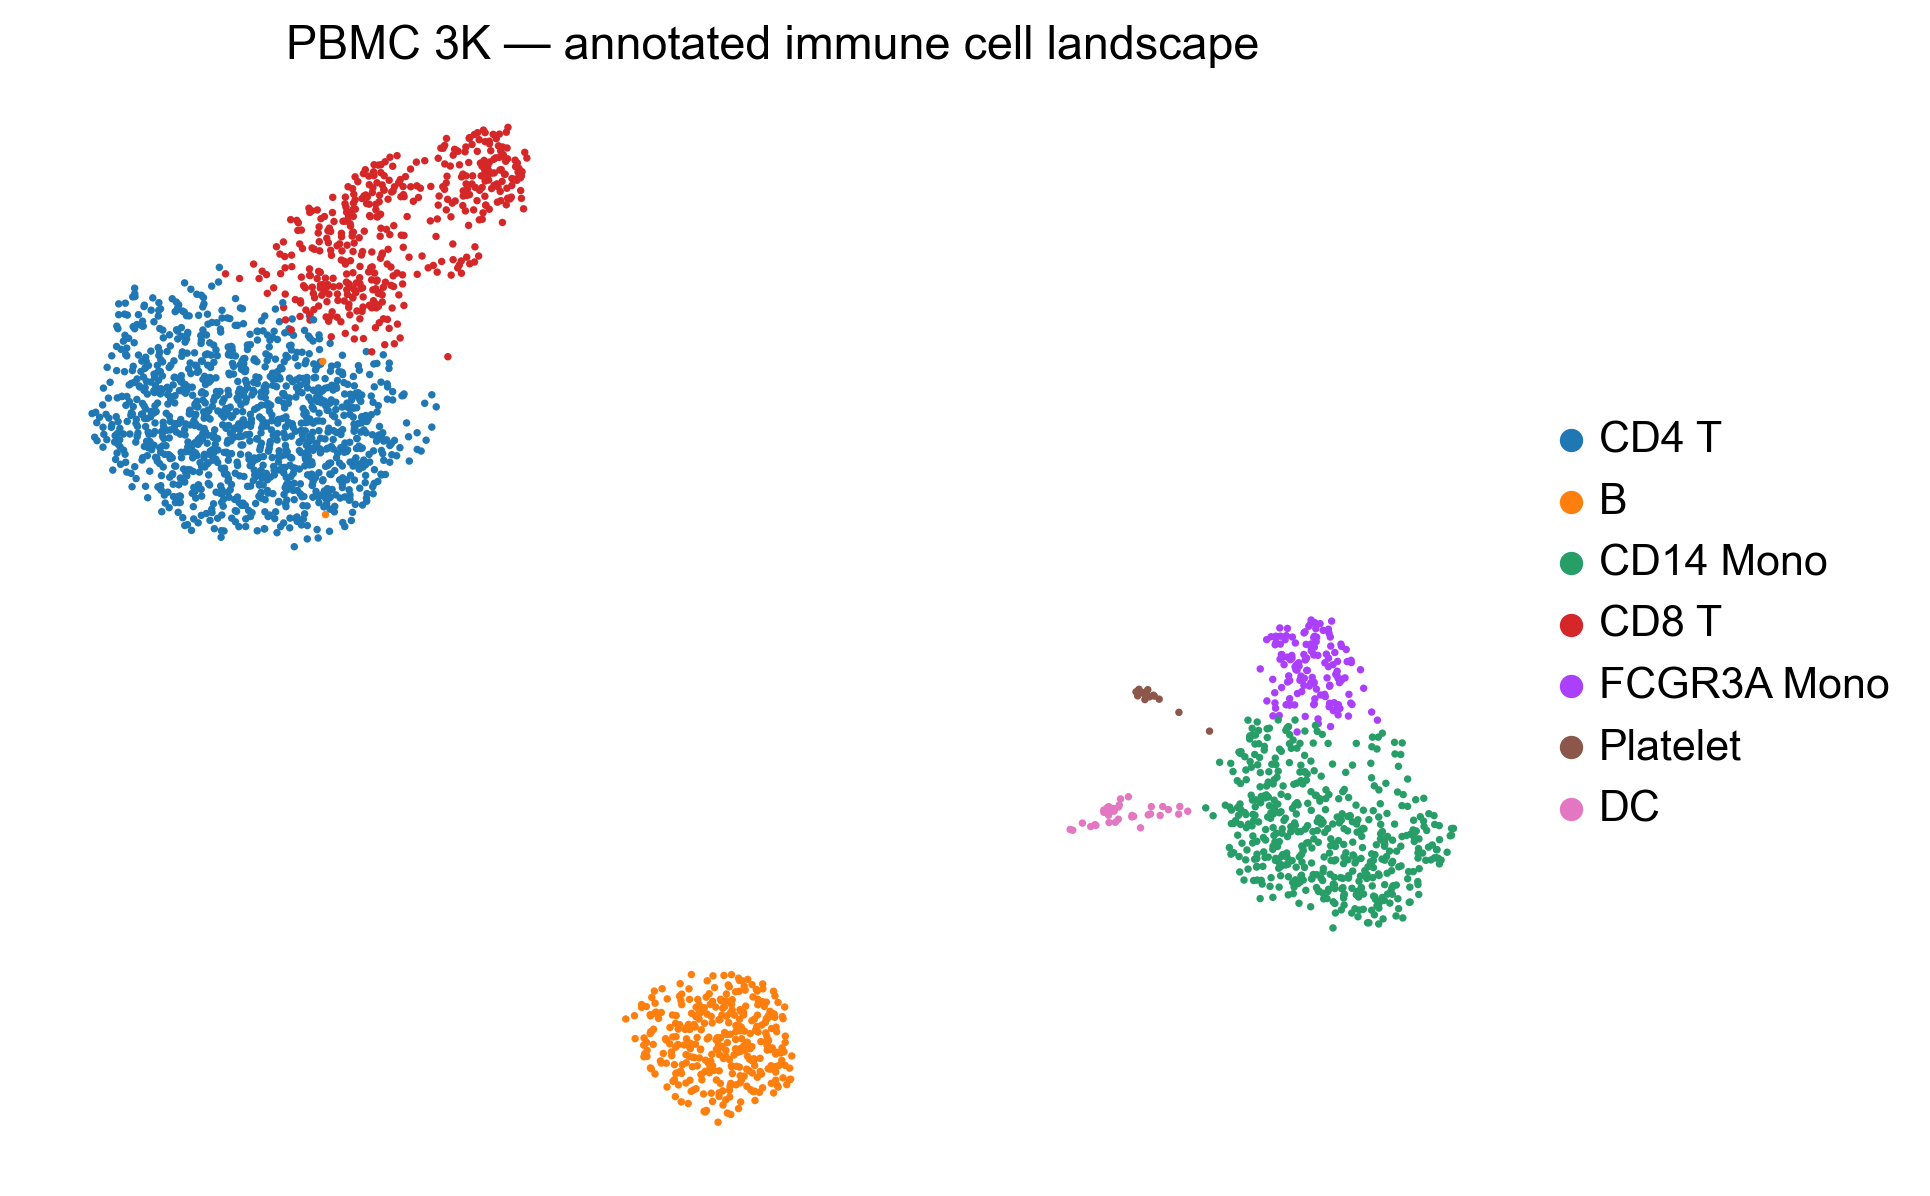

In [15]:
fig = sc.pl.umap(
    adata,
    color='cell_type',
    legend_loc='right margin',
    title='PBMC 3K — annotated immune cell landscape',
    frameon=False,
    size=20,
    return_fig=True,
)
fig.set_size_inches(8, 6)
pu.save_figure(fig, 'hero_umap_celltypes', out_dir=FIG_DIR)
plt.show()

### Figure: Marker dotplot by annotated cell type

  saved ../figures/07_marker_dotplot_byCellType.png
  saved ../figures/07_marker_dotplot_byCellType.tiff
  saved ../figures/07_marker_dotplot_byCellType.pdf


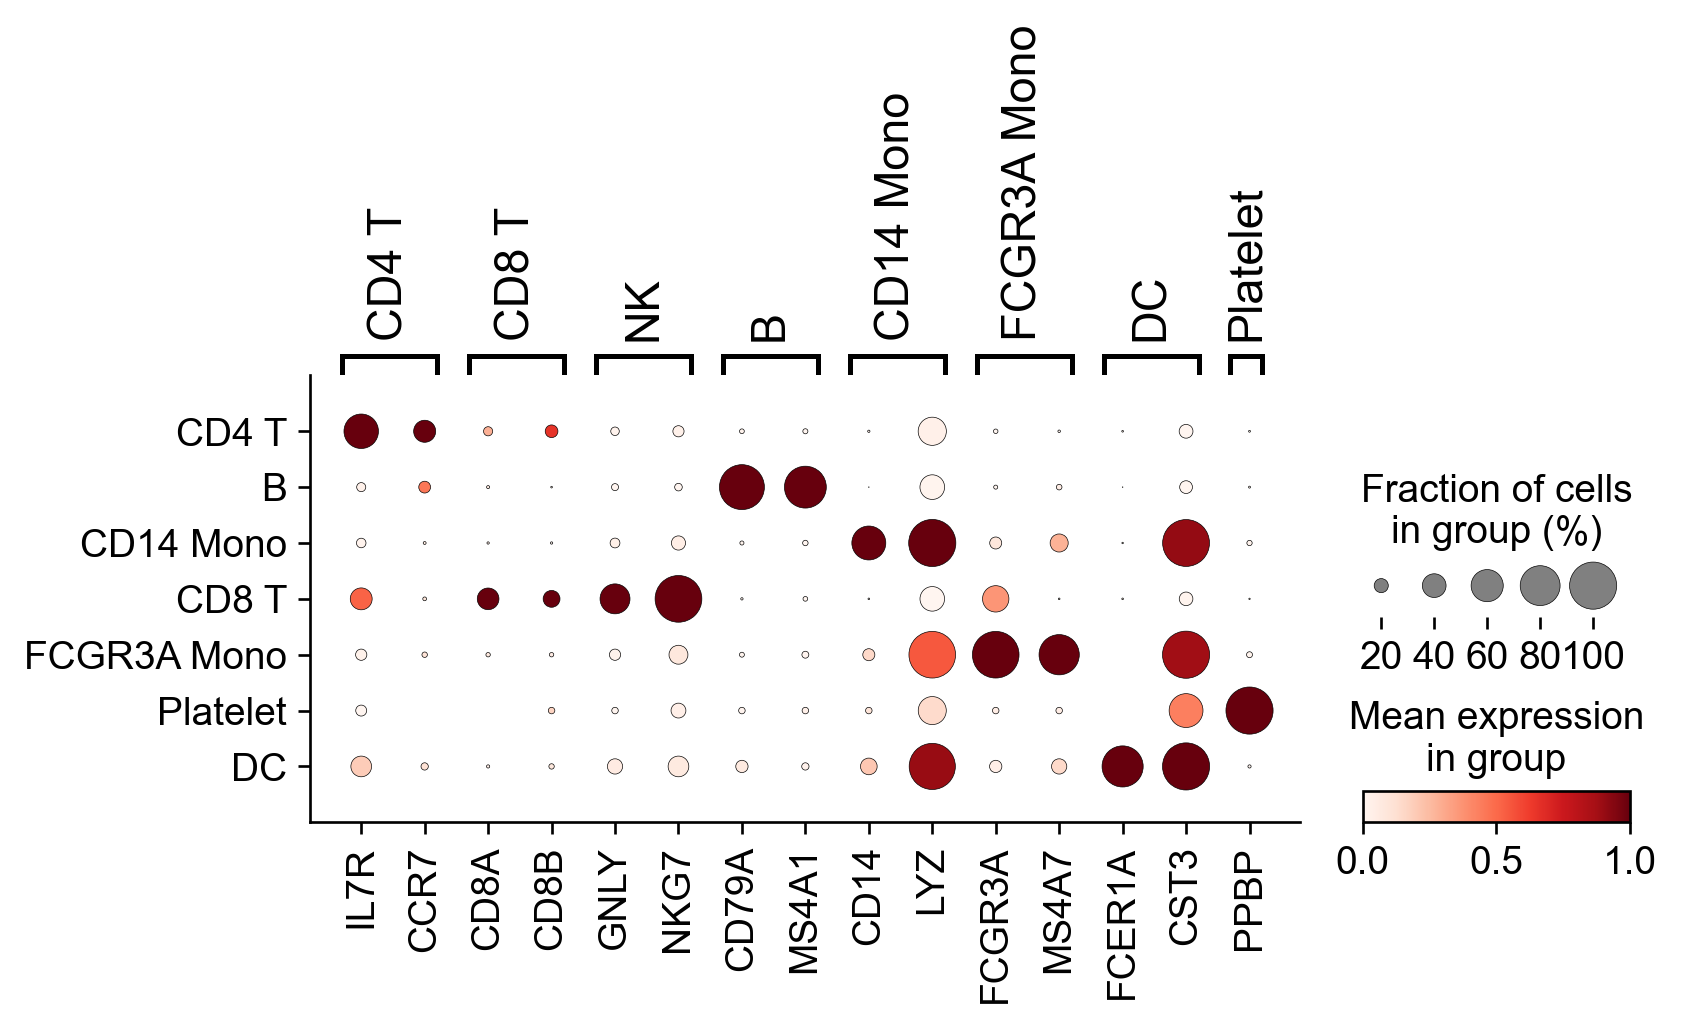

In [16]:
sc.pl.dotplot(adata, marker_genes, groupby='cell_type',
              standard_scale='var', show=False, save=None)
fig = plt.gcf()
pu.save_figure(fig, '07_marker_dotplot_byCellType', out_dir=FIG_DIR)
plt.show()

### Figure: Stacked violin of canonical markers

  saved ../figures/08_stacked_violin_markers.png
  saved ../figures/08_stacked_violin_markers.tiff


  saved ../figures/08_stacked_violin_markers.pdf


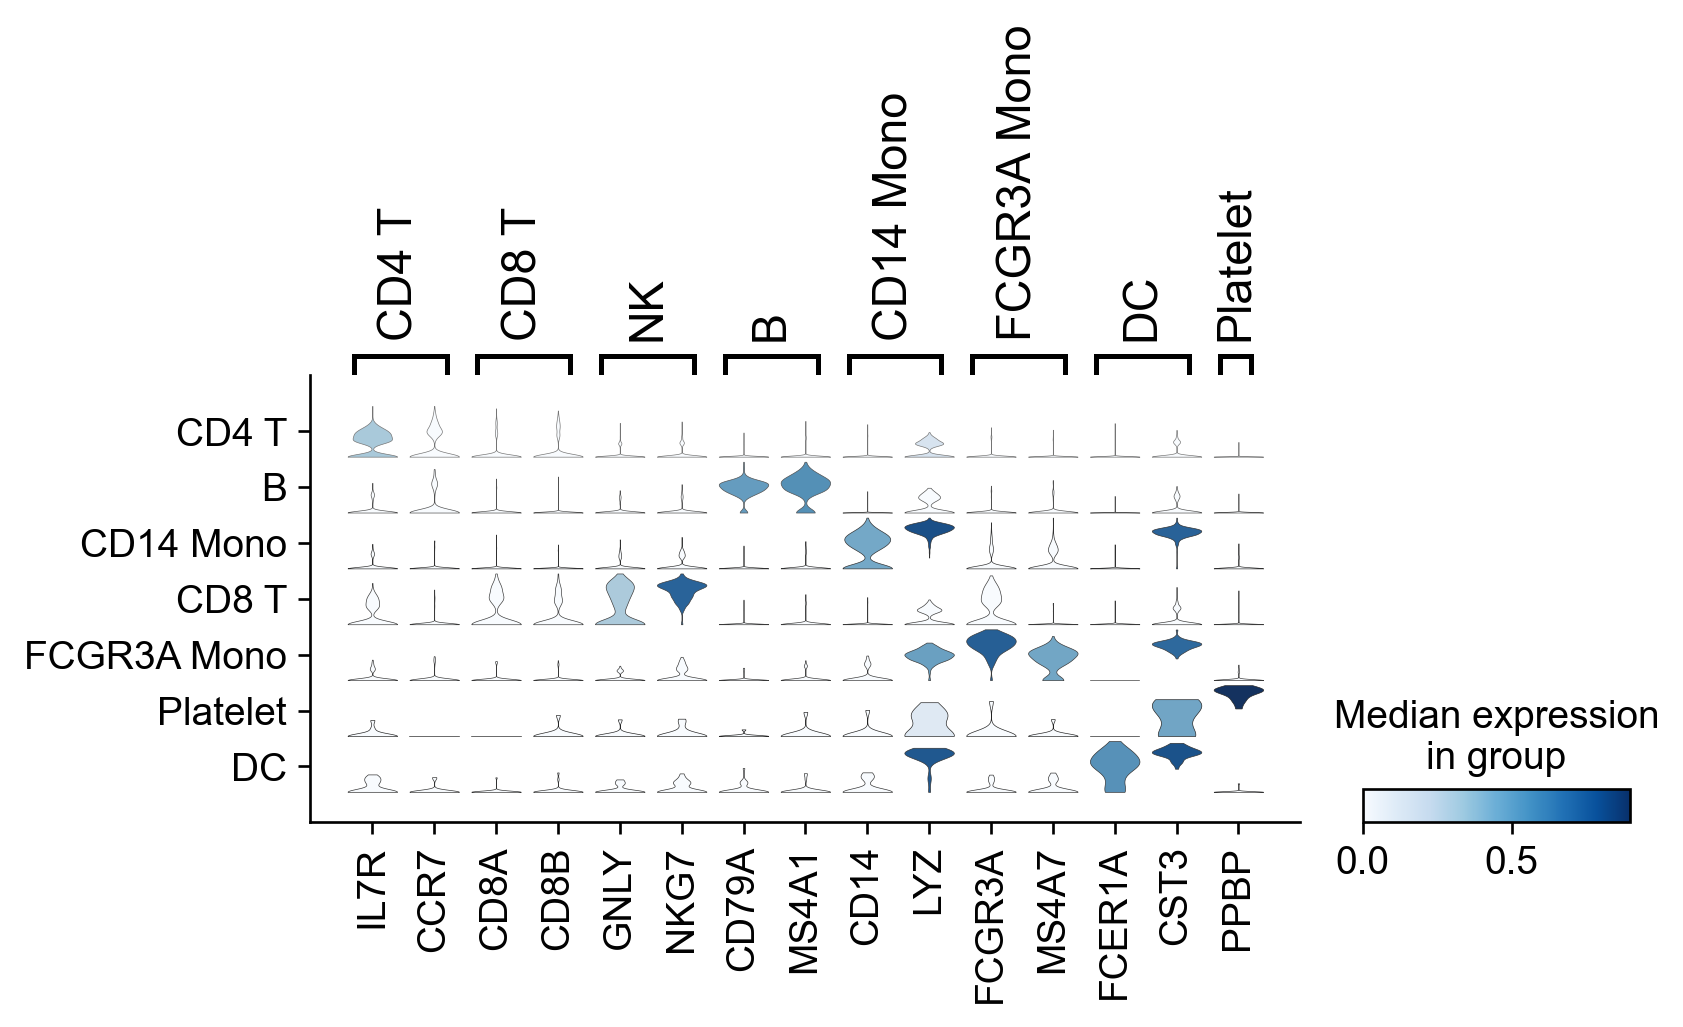

In [17]:
sc.pl.stacked_violin(adata, marker_genes, groupby='cell_type',
                     standard_scale='var', show=False, save=None)
fig = plt.gcf()
pu.save_figure(fig, '08_stacked_violin_markers', out_dir=FIG_DIR)
plt.show()

### Figure: Cell type composition

  saved ../figures/09_celltype_composition.png
  saved ../figures/09_celltype_composition.tiff
  saved ../figures/09_celltype_composition.pdf


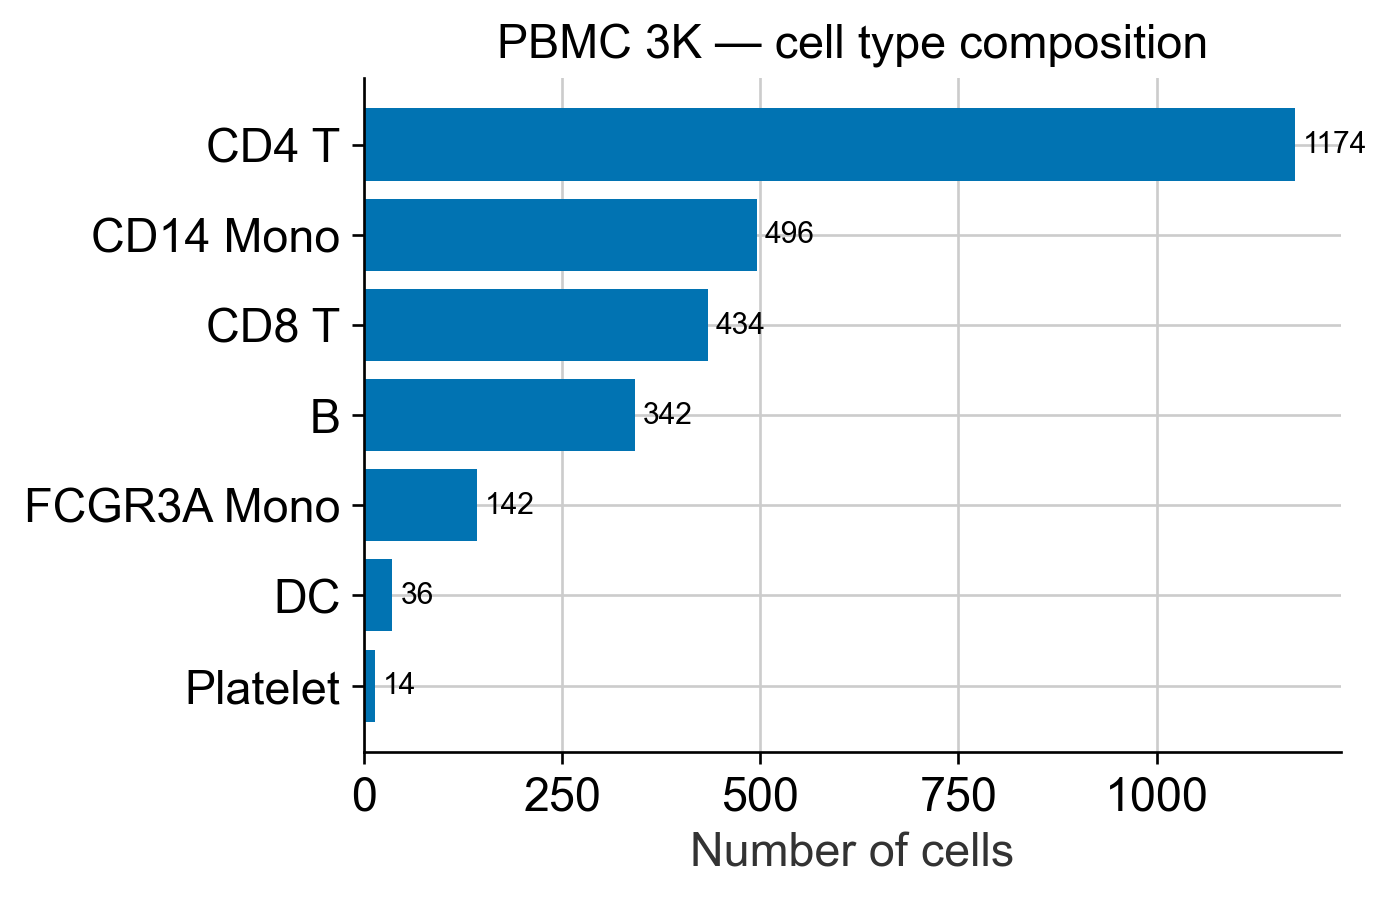

In [18]:
ct_counts = adata.obs['cell_type'].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(ct_counts.index, ct_counts.values, color='#0173B2')
ax.set_xlabel('Number of cells')
ax.set_title('PBMC 3K — cell type composition')
for i, v in enumerate(ct_counts.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
fig.tight_layout()
pu.save_figure(fig, '09_celltype_composition', out_dir=FIG_DIR)
plt.show()

## 8. Export results

In [19]:
# save processed AnnData
adata.write_h5ad(RESULTS_DIR / 'pbmc3k_processed.h5ad')

# export marker gene table (top 25 per cluster) as CSV
marker_df = sc.get.rank_genes_groups_df(adata, group=None)
marker_df.to_csv(RESULTS_DIR / 'marker_genes_per_cluster.csv', index=False)

# QC summary
qc_summary = pu.quick_qc_summary(adata)
print("QC summary (post-filtering):")
for k, v in qc_summary.items():
    print(f"  {k}: {v}")

print(f"\nAll figures saved to: {FIG_DIR.resolve()}")
print(f"Processed data saved to: {RESULTS_DIR.resolve()}")

QC summary (post-filtering):
  n_cells: 2638
  n_genes: 13714
  median_counts: 2214.0
  median_genes_per_cell: 820.0
  pct_mt_median: 2.0086193084716797

All figures saved to: /home/marko-b2/upwork_portfolio/01_pbmc3k_basics/figures
Processed data saved to: /home/marko-b2/upwork_portfolio/01_pbmc3k_basics/results


## 9. Done

**Outputs:**
- 9 figures in `figures/` (each in PNG + TIFF + PDF)
- `hero_umap_celltypes.png` — Upwork portfolio thumbnail
- `pbmc3k_processed.h5ad` — fully processed AnnData
- `marker_genes_per_cluster.csv` — DE results table

**Next:** write the 2-page mini-report in `report/report.qmd` and commit everything to GitHub.